In [17]:
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit.visualization import *
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import transpile
from qiskit_ibm_runtime.fake_provider import *
from qiskit_aer import AerSimulator
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [3]:
service = QiskitRuntimeService()
# Real Backend
backend_qc = service.least_busy(operational=True, simulator=False)
# Fake Backend(Noisy Simulator)_Try Other FakeBackend!
backend_sim = FakeArmonkV2()
# backend_sim = AerSimulator() # Ideal Simulator
# Choose Backend
backend = backend_sim

qiskit_runtime_service.__init__:WARNING:2025-12-17 13:07:28,836: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium), the available account instances are: 0_UNIST_UNIST -eu, 0_UNIST_UNIST. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2025-12-17 13:07:29,721: Loading instance: 0_UNIST_UNIST -eu, plan: premium
qiskit_runtime_service.backends:WARNING:2025-12-17 13:07:31,355: Loading instance: 0_UNIST_UNIST, plan: premium
qiskit_runtime_service.backends:WARNING:2025-12-17 13:07:36,288: Using instance: 0_UNIST_UNIST -eu, plan: premium


In [14]:
# Build Sampler
sampler = Sampler(backend)
# Transpilation pass manager automatically configured for a given backend and optimization level.
pm = generate_preset_pass_manager(backend=backend, optimization_level=0) 
qc_pm = pm.run(qc)
qc_pm.draw(output = "mpl")
# Run Sampler
shot_num = 2048
job = sampler.run([qc_pm], shots = shot_num)
# Get result from your job
result = job.result()
# get counts for Sampler jobs
count = result[0].data.c.get_counts()
# Show your work!
print(f" > Counts: {count}")

 > Counts: {'1': 1990, '0': 58}


In [15]:
# Now, Let’s Do It in Session! 
t = []
prob1 = []
shot_num = 1000
t_range = 300 # Plot data 0 us ~ 300 us
f_detune= 2E4 # To simulate detuning in FakeProvider, define detuning frequency

In [16]:
with Session(backend=backend) as session:    
    sampler = Sampler(mode=session)    
    for delay in range(t_range+1):        
        qc=QuantumCircuit(1,1)        
        qc.x(0)                
        qc.h(0)        
        qc.delay(delay,unit = 'us' ) # give … us delay        
        # Only for FakeProvider(Simulator case), Don't Use In Real Backend Case.        
        # qc.rz(2*np.pi*f_detune*delay*1e-6, 0) 
        qc.h(0)        
        qc.measure(0,0)        
        pm = generate_preset_pass_manager(backend=backend, optimization_level=0)         
        job = sampler.run([qc_pm], shots = shot_num)        
        result = job.result()        
        count = result[0].data.c.get_counts()               
        t.append(delay)        
        qc_pm = pm.run(qc)       
        prob1.append(count['1']/shot_num)

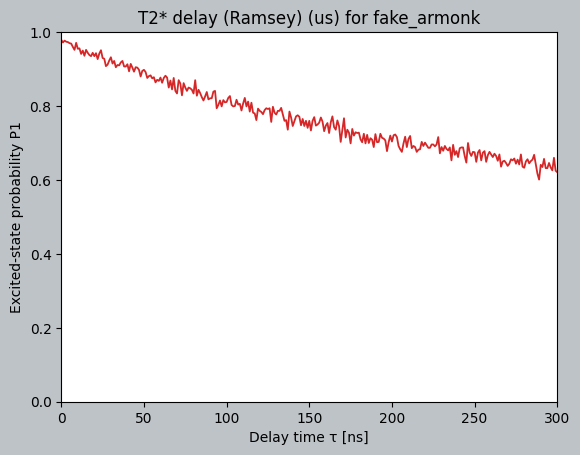

In [20]:
plt.plot(t, prob1, color='tab:Red', linestyle='-', marker='',lw=1.3)
plt.gcf().set_facecolor('#bdc3c7')
plt.xlim(0,t_range)
plt.ylim(0, 1)
plt.xlabel('Delay time τ [ns]')
plt.ylabel('Excited-state probability P1')
plt.title('T2* delay (Ramsey) (us) for '+ str(backend.name))
t_ramsey = t
p1_ramsey = prob1

In [27]:
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# 1 Qubit and 1 classical bit
qc = QuantumCircuit(1,1)
qc.x(0)  # |0⟩ → |1⟩

# Hahn Echo 회로 구성
delay = 10
qc.h(0)
qc.delay(delay/2, unit='us')  # 첫 번째 절반 지연
qc.x(0)  # π-pulse (echo pulse)
qc.delay(delay/2, unit='us')  # 두 번째 절반 지연
qc.h(0)
qc.measure(0,0)

# 트랜스파일 및 실행
pm = generate_preset_pass_manager(backend=backend, optimization_level=0) 
qc_pm = pm.run(qc)

sampler = Sampler(backend)
shot_num = 2048
job = sampler.run([qc_pm], shots=shot_num)  # ✅ qc_pm 사용
result = job.result()
count = result[0].data.c.get_counts()
print(f" > Counts: {count}")

# Session을 사용한 T2 Hahn Echo 실험
t = []
prob1 = []
shot_num = 1000
t_range = 300

with Session(backend=backend) as session:    
    sampler = Sampler(mode=session)    
    for delay in range(t_range+1):        
        qc = QuantumCircuit(1,1)        
        qc.x(0)                
        qc.h(0)        
        qc.delay(delay/2, unit='us')  # 절반 지연
        qc.x(0)  # Echo pulse
        qc.delay(delay/2, unit='us')  # 절반 지연
        qc.h(0)        
        qc.measure(0,0)        
        
        pm = generate_preset_pass_manager(backend=backend, optimization_level=0)         
        qc_pm = pm.run(qc)  # 트랜스파일
        job = sampler.run([qc_pm], shots=shot_num)  # ✅ 트랜스파일된 회로 사용
        result = job.result()        
        count = result[0].data.c.get_counts()               
        t.append(delay)        
        prob1.append(count.get('1', 0)/shot_num)  # '1'이 없을 경우 대비


 > Counts: {'1': 1962, '0': 86}


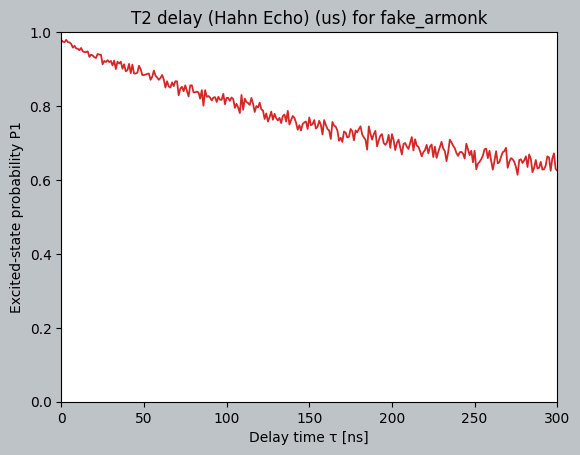

In [ ]:
# 간단하게plot 하고싶으면plt.plot(t,prob1) 만 작성해도 됩니다.
import matplotlib.pyplot as plt
plt.plot(t,prob1) 
plt.plot(t, prob1, color='tab:Red', linestyle='-', marker='',lw=1.3)
plt.gcf().set_facecolor('#bdc3c7')
plt.xlim(0,t_range)
plt.ylim(0, 1)
plt.xlabel('Delay time τ [ns]')
plt.ylabel('Excited-state probability P1')
plt.title('T2 delay (Hahn Echo) (us) for '+ str(backend.name))
t_hahn_echo = t
p1_hahn_echo = prob1
